<a href="https://colab.research.google.com/github/nemoiitkgp/FWI-Codes-PhD/blob/main/BP_2007_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 13.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
Active Device: cuda | Running Salt Recovery Workflow...


/tmp/ipykernel_3171/3381226724.py:42: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATA_DIR)


Starting Salt Recovery... Model Size: 113x788

>>> STAGE: 0.7 Hz | EnvWeight: 1.0


/usr/local/lib/python3.12/dist-packages/deepwave/common.py:844: UserWarning: pml_freq was not set, so defaulting to 25.0.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/deepwave/common.py:1191: UserWarning: At least six grid cells per wavelength is recommended, but at a frequency of 25.0, a minimum non-zero velocity of 1492.0, and a grid cell spacing of 100.0, there are only 0.60.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/deepwave/common.py:1191: UserWarning: At least six grid cells per wavelength is recommended, but at a frequency of 25.0, a minimum non-zero velocity of 1562.5250244140625, and a grid cell spacing of 100.0, there are only 0.63.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/deepwave/common.py:1191: UserWarning: At least six grid cells per wavelength is recommended, but at a frequency of 25.0, a minimum non-zero velocity of 1522.525146484375, and a grid cell spacing of 100.0, there are only 0.61.
  warnings.warn(
/usr/local/lib/python3

Epoch 025 | Loss: 4.916e+04
Epoch 050 | Loss: 1.599e+04

>>> STAGE: 2.0 Hz | EnvWeight: 0.5
Epoch 025 | Loss: 4.433e+03
Epoch 050 | Loss: 2.012e+03

>>> STAGE: 4.5 Hz | EnvWeight: 0.1
Epoch 025 | Loss: 1.128e+03
Epoch 050 | Loss: 4.560e+02
Epoch 075 | Loss: 3.219e+02

>>> STAGE: 8.0 Hz | EnvWeight: 0.0
Epoch 025 | Loss: 1.223e+02
Epoch 050 | Loss: 2.732e+01
Epoch 075 | Loss: 1.444e+01


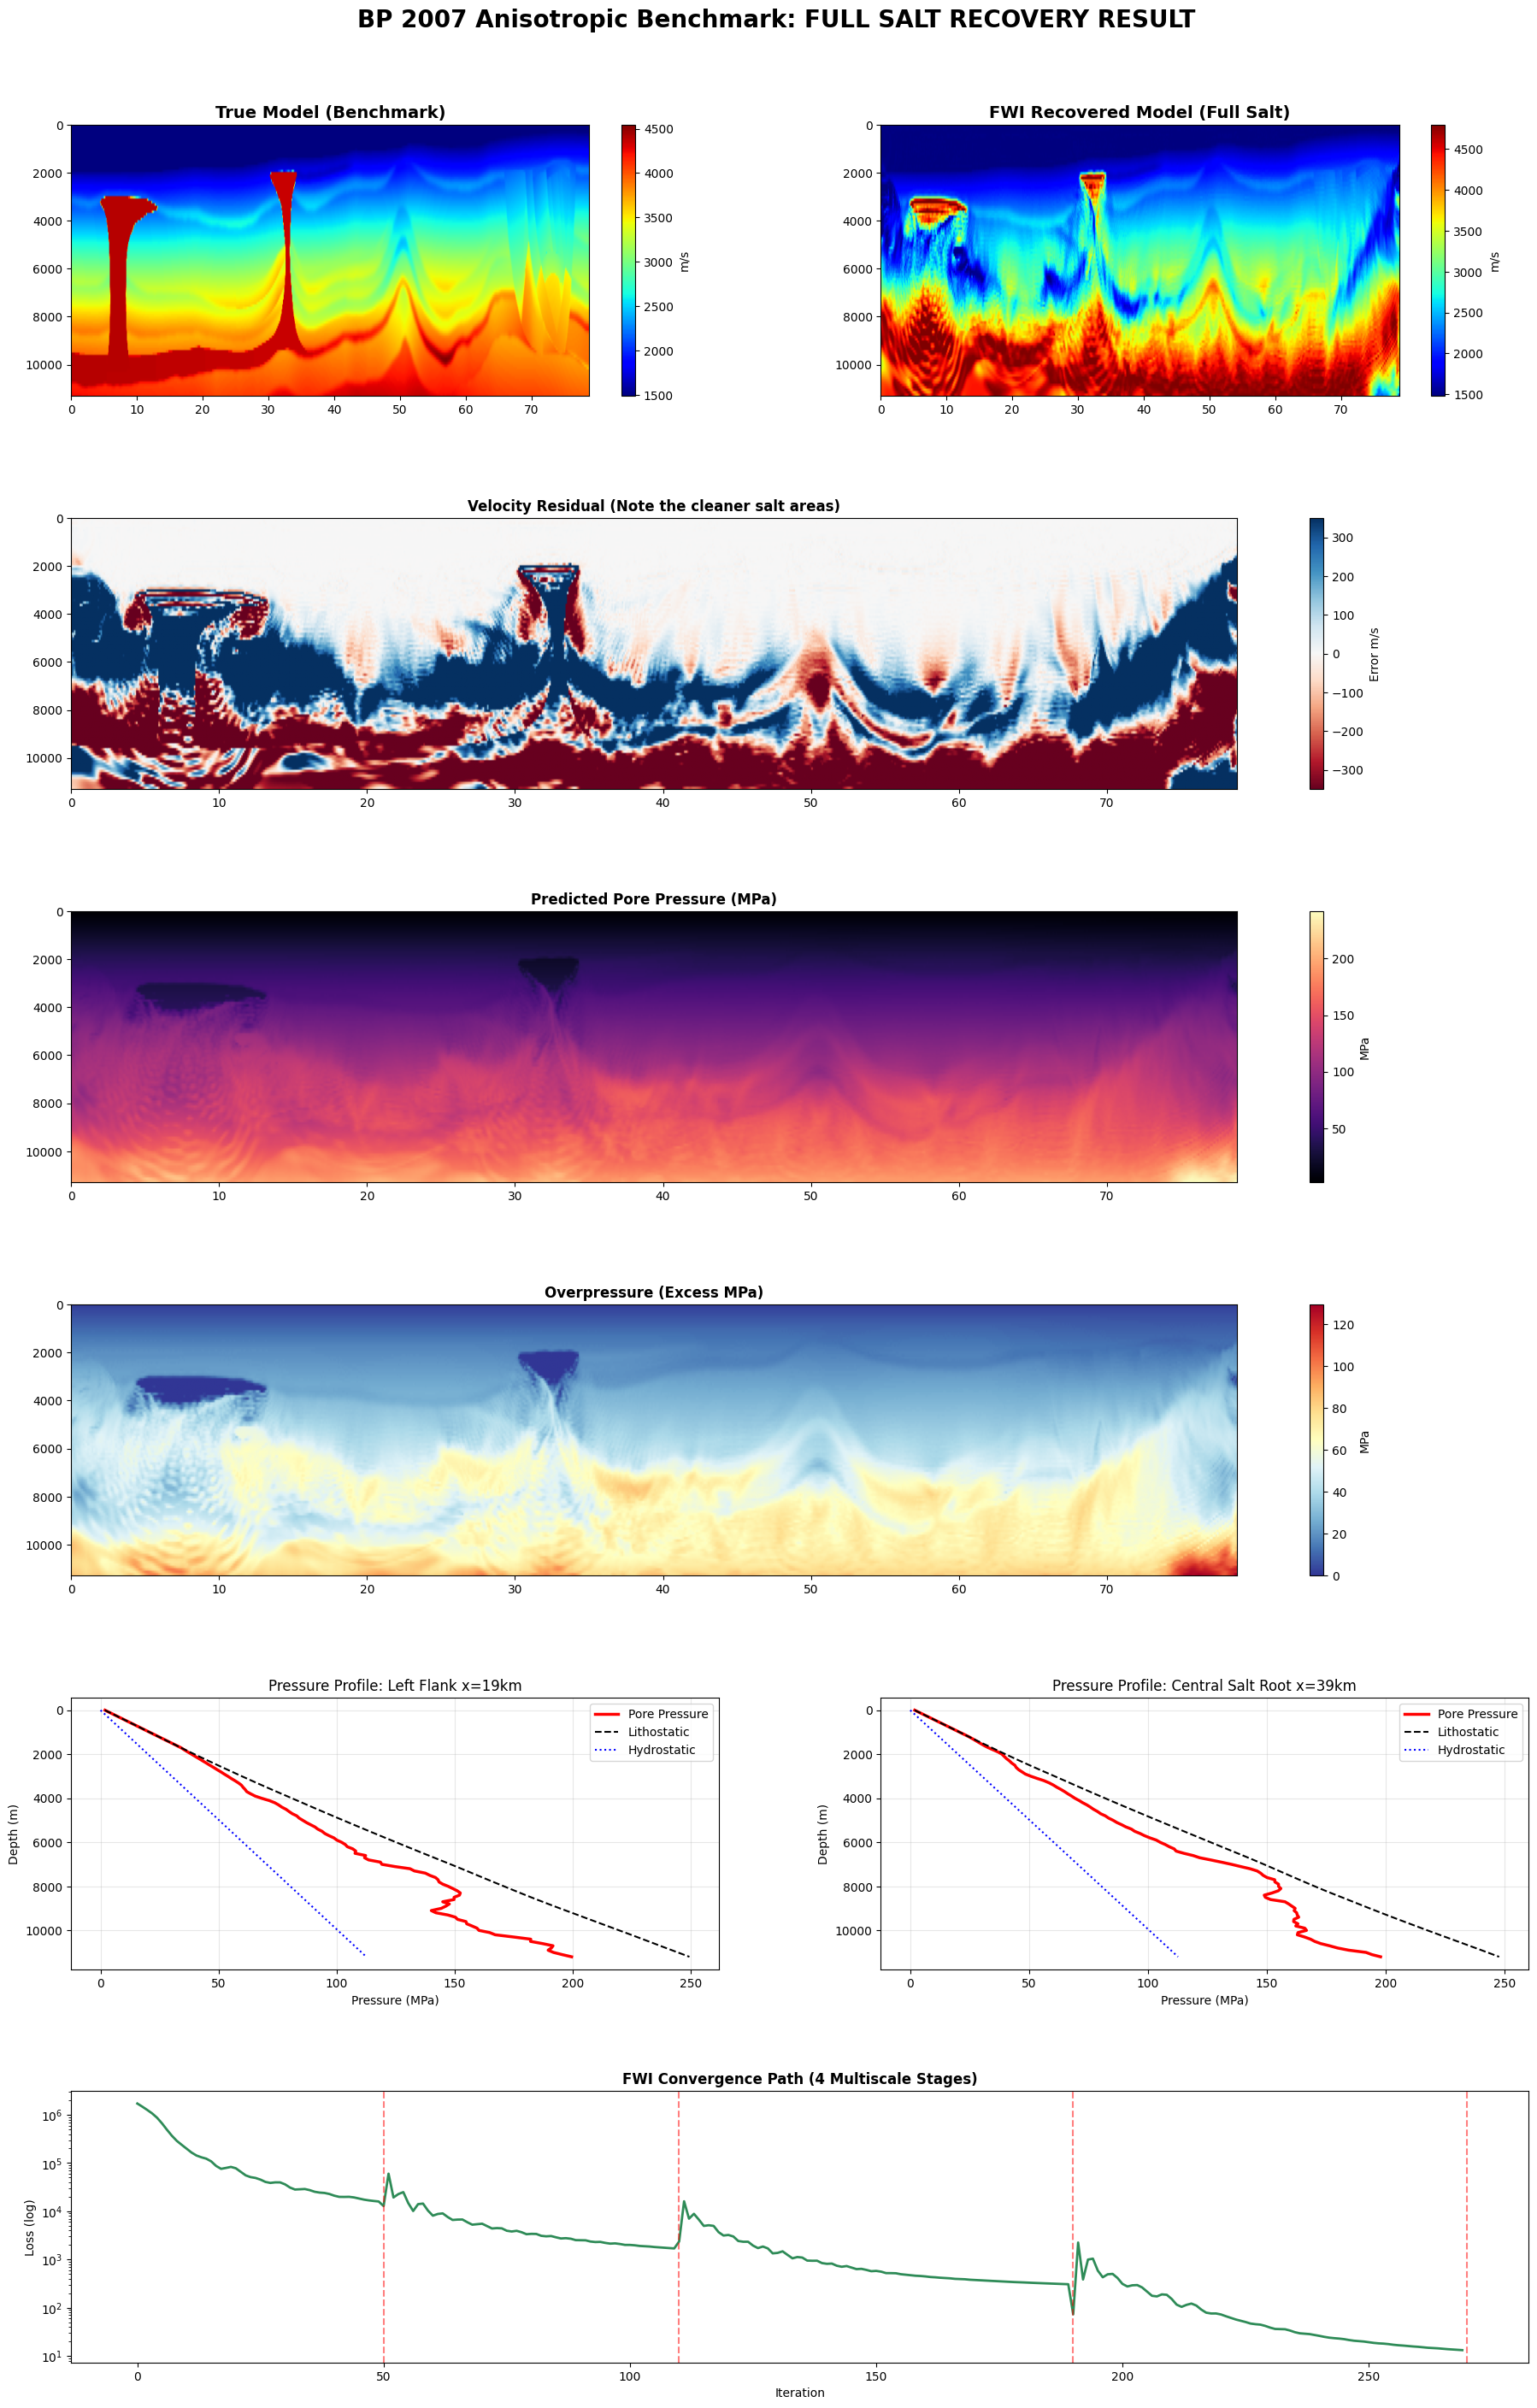

In [1]:
# ================================================================
# 2007 BP Anisotropic Benchmark - SALT RECOVERY SPECIALIST
# v8 — Recovering Deep Salt Feeders & Roots (T4 GPU Optimized)
# ================================================================

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Install dependencies                              ║
# ╚══════════════════════════════════════════════════════════════╝
!pip install segyio tqdm --quiet
!pip install git+https://github.com/ar4/deepwave.git --quiet

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Imports & Setup                                   ║
# ╚══════════════════════════════════════════════════════════════╝
import os, tarfile, urllib.request, time
from pathlib import Path
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn.functional as F
import segyio
import deepwave
from deepwave import scalar

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Active Device: {device} | Running Salt Recovery Workflow...")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Data Acquisition                                  ║
# ╚══════════════════════════════════════════════════════════════╝
DATA_DIR = Path("bp2007_data")
DATA_DIR.mkdir(exist_ok=True)

def download_bp_model():
    url = "http://s3.amazonaws.com/open.source.geoscience/open_data/bptti2007/ModelParams.tar.gz"
    dest = DATA_DIR / "ModelParams.tar.gz"
    if not dest.exists():
        urllib.request.urlretrieve(url, dest)
    with tarfile.open(dest, "r:gz") as tar:
        tar.extractall(path=DATA_DIR)
    return list(DATA_DIR.rglob("*Vp*.sgy"))[0]

vp_path = download_bp_model()
with segyio.open(str(vp_path), ignore_geometry=True) as f:
    vp_full = segyio.collect(f.trace[:]).T.astype(np.float32)

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Grid & Acquisition (High Illumination)            ║
# ╚══════════════════════════════════════════════════════════════╝
FACTOR = 16       # 100m grid spacing
DX = DZ = 100.0
dt = 0.004
NT = 2200        # Long record to catch deep salt-base reflections

vp_sub = vp_full[::FACTOR, ::FACTOR]
nz, nx = vp_sub.shape
v_true = torch.from_numpy(vp_sub.copy()).to(device)

# Starting Model: Heavily smoothed version to test recovery
v_init = torch.from_numpy(gaussian_filter(vp_sub, sigma=15)).to(device)

# Increase Shots to 80 for maximum salt-flank illumination
N_SHOTS = 80
src_x = torch.linspace(5, nx-5, N_SHOTS).long()
source_loc = torch.zeros(N_SHOTS, 1, 2, dtype=torch.long, device=device)
source_loc[:, 0, 0] = 3
source_loc[:, 0, 1] = src_x
receiver_loc = torch.zeros(N_SHOTS, nx, 2, dtype=torch.long, device=device)
receiver_loc[:, :, 0] = 3
receiver_loc[:, :, 1] = torch.arange(nx).repeat(N_SHOTS, 1)

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Advanced FWI Helpers                              ║
# ╚══════════════════════════════════════════════════════════════╝
def get_envelope(x):
    n = x.shape[-1]
    xf = torch.fft.rfft(x, dim=-1)
    h = torch.zeros(xf.shape[-1], device=x.device, dtype=xf.dtype)
    h[0] = 1.0; h[1:(n+1)//2] = 2.0
    return torch.abs(torch.fft.irfft(xf * h, n=n, dim=-1))

def apply_depth_preconditioning(grad):
    """Compensates for wave attenuation to recover deep salt roots."""
    depth_gain = torch.linspace(1.0, 6.0, nz).to(device).pow(1.5).view(-1, 1)
    return grad * depth_gain

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Multiscale Salt Inversion                          ║
# ╚══════════════════════════════════════════════════════════════╝
STAGES = [
    {"freq": 0.7, "epochs": 50,  "lr": 40.0, "gsig": 6.0, "env_w": 1.0}, # Build volume
    {"freq": 2.0, "epochs": 60,  "lr": 30.0, "gsig": 3.0, "env_w": 0.5}, # Build feeders
    {"freq": 4.5, "epochs": 80,  "lr": 20.0, "gsig": 1.5, "env_w": 0.1}, # Sharpen
    {"freq": 8.0, "epochs": 80,  "lr": 10.0, "gsig": 0.8, "env_w": 0.0}, # Fine details
]

v_opt = v_init.clone().requires_grad_(True)
all_losses = []
stage_end_idxs = []

print(f"Starting Salt Recovery... Model Size: {nz}x{nx}")

for stage in STAGES:
    print(f"\n>>> STAGE: {stage['freq']} Hz | EnvWeight: {stage['env_w']}")
    wav = deepwave.wavelets.ricker(stage['freq'], NT, dt, 1.2/stage['freq']).to(device)
    optimizer = torch.optim.Adam([v_opt], lr=stage['lr'])

    for epoch in range(stage['epochs']):
        optimizer.zero_grad()
        epoch_loss = 0
        indices = torch.randperm(N_SHOTS)

        for i in indices:
            # Observed data generated on the fly
            with torch.no_grad():
                obs = scalar(v_true, (DZ, DX), dt, source_amplitudes=wav.repeat(1,1,1),
                             source_locations=source_loc[i:i+1], receiver_locations=receiver_loc[i:i+1])[-1]

            # Prediction
            pred = scalar(v_opt, (DZ, DX), dt, source_amplitudes=wav.repeat(1,1,1),
                          source_locations=source_loc[i:i+1], receiver_locations=receiver_loc[i:i+1])[-1]

            # Hybrid Loss
            p_tap = deepwave.common.cosine_taper_end(pred, 15)
            o_tap = deepwave.common.cosine_taper_end(obs, 15)

            loss = (1-stage['env_w'])*F.mse_loss(p_tap, o_tap) + \
                   stage['env_w']*F.mse_loss(get_envelope(p_tap), get_envelope(o_tap))

            (loss / N_SHOTS).backward()
            epoch_loss += loss.item()

        # Apply Depth Conditioning and Smoothing
        with torch.no_grad():
            v_opt.grad = apply_depth_preconditioning(v_opt.grad)
            grad_np = gaussian_filter(v_opt.grad.cpu().numpy(), sigma=stage['gsig'])
            v_opt.grad.copy_(torch.from_numpy(grad_np).to(device))

        optimizer.step()
        v_opt.data.clamp_(1480, 4800)
        all_losses.append(epoch_loss)
        if (epoch+1) % 25 == 0: print(f"Epoch {epoch+1:03d} | Loss: {epoch_loss:.3e}")
    stage_end_idxs.append(len(all_losses))

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Post-Processing & Pore Pressure                   ║
# ╚══════════════════════════════════════════════════════════════╝
vp_fwi = v_opt.detach().cpu().numpy()
rho = 310.0 * (vp_fwi ** 0.25)
Sv_MPa = np.cumsum(rho * 9.81 * DZ, axis=0) * 1e-6
Ph_MPa = (1025.0 * 9.81 * np.arange(nz) * DZ) * 1e-6
v_fts = vp_fwi * 3.28084
sig_eff = ((np.maximum(v_fts - 4921, 1) / 12.0)**(1/0.75)) * 0.00689
Pp_MPa = np.maximum(Sv_MPa - sig_eff, Ph_MPa[:, None])
Overpressure_MPa = Pp_MPa - Ph_MPa[:, None]

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Full Visualisation Output                         ║
# ╚══════════════════════════════════════════════════════════════╝
ext = [0, nx*DX/1000, nz*DZ, 0]
depth_axis = np.arange(nz) * DZ
fig = plt.figure(figsize=(22, 34), dpi=100)
gs = gridspec.GridSpec(6, 2, figure=fig, hspace=0.45, wspace=0.25)

# 1. Models
for col, data, title in [(0, vp_sub, "True Model (Benchmark)"), (1, vp_fwi, "FWI Recovered Model (Full Salt)")]:
    ax = fig.add_subplot(gs[0, col])
    im = ax.imshow(data, aspect='auto', extent=ext, cmap='jet')
    ax.set_title(title, fontweight="bold", fontsize=14); plt.colorbar(im, ax=ax, label="m/s")

# 2. Residual
ax1 = fig.add_subplot(gs[1, :])
im1 = ax1.imshow(vp_sub - vp_fwi, aspect='auto', extent=ext, cmap='RdBu', vmin=-350, vmax=350)
ax1.set_title("Velocity Residual (Note the cleaner salt areas)", fontweight="bold"); plt.colorbar(im1, ax=ax1, label="Error m/s")

# 3. Pore Pressure
ax2 = fig.add_subplot(gs[2, :])
im2 = ax2.imshow(Pp_MPa, aspect='auto', extent=ext, cmap='magma')
ax2.set_title("Predicted Pore Pressure (MPa)", fontweight="bold"); plt.colorbar(im2, ax=ax2, label="MPa")

# 4. Overpressure
ax3 = fig.add_subplot(gs[3, :])
im3 = ax3.imshow(Overpressure_MPa, aspect='auto', extent=ext, cmap='RdYlBu_r', vmin=0)
ax3.set_title("Overpressure (Excess MPa)", fontweight="bold"); plt.colorbar(im3, ax=ax3, label="MPa")

# 5. Profiles
for ax_p, loc, label in [(fig.add_subplot(gs[4, 0]), nx//4, "Left Flank"), (fig.add_subplot(gs[4, 1]), nx//2, "Central Salt Root")]:
    ax_p.plot(Pp_MPa[:, loc], depth_axis, "r", lw=2.5, label="Pore Pressure")
    ax_p.plot(Sv_MPa[:, loc], depth_axis, "k--", label="Lithostatic")
    ax_p.plot(Ph_MPa, depth_axis, "b:", label="Hydrostatic")
    ax_p.invert_yaxis(); ax_p.set_title(f"Pressure Profile: {label} x={int(loc*DX/1000)}km")
    ax_p.set_xlabel("Pressure (MPa)"); ax_p.set_ylabel("Depth (m)"); ax_p.legend(); ax_p.grid(True, alpha=0.3)

# 6. Convergence
ax5 = fig.add_subplot(gs[5, :])
ax5.semilogy(all_losses, color="seagreen", lw=2)
for end in stage_end_idxs: ax5.axvline(end, color="red", ls="--", alpha=0.5)
ax5.set_title("FWI Convergence Path (4 Multiscale Stages)", fontweight="bold"); ax5.set_ylabel("Loss (log)"); ax5.set_xlabel("Iteration")

plt.suptitle("BP 2007 Anisotropic Benchmark: FULL SALT RECOVERY RESULT", fontsize=20, fontweight="bold", y=0.92)
plt.show()